<a href="https://colab.research.google.com/github/ninjaabhinav/classical-ml-projects/blob/main/Advance_house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Housing (1).csv')

In [30]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [32]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


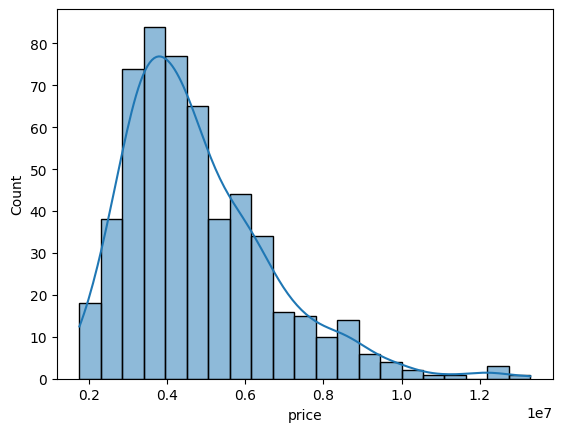

Skewness:  1.2122388370279802


In [33]:
sns.histplot(df['price'], kde=True)
plt.show()

print('Skewness: ',df['price'].skew())

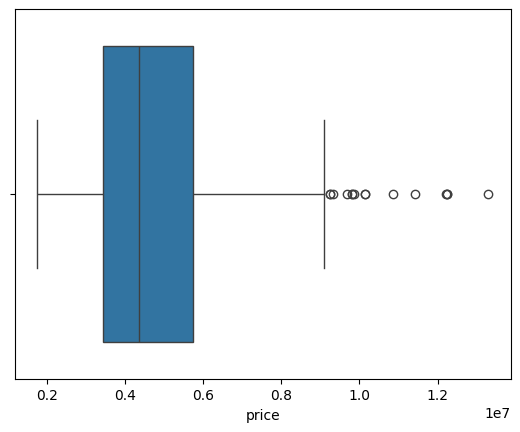

In [34]:
sns.boxplot(x = df['price'])
plt.show()

In [35]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [52]:
df["area_per_bedroom"] = df["area"] / df["bedrooms"]
df["area_squared"] = df["area"] * df["area"]

In [53]:
df['log_price'] = np.log1p(df['price'])
print(df['log_price'].skew())

0.14086281102108905


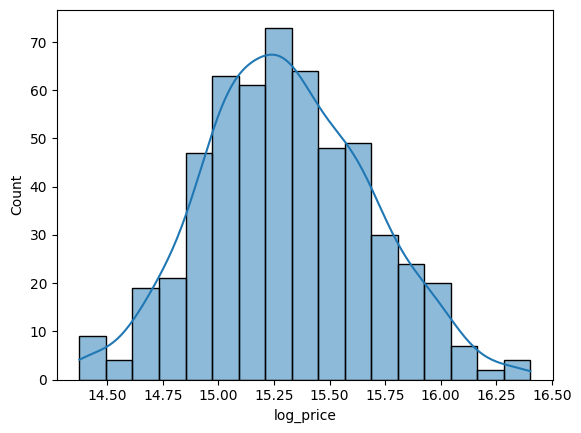

0.14086281102108905


In [54]:
sns.histplot(df['log_price'], kde=True)
plt.show()
print(df['log_price'].skew())

In [55]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_bedroom,log_price,area_squared
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1855.0,16.403275,55056400
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,2240.0,16.321037,80281600
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,3320.0,16.321037,99201600
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1875.0,16.318175,56250000
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1855.0,16.250001,55056400


In [56]:
X = df.drop(['price', 'log_price'], axis=1)
y = df['log_price']

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'area_per_bedroom', 'area_squared'],
      dtype='object')
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encode', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])

In [61]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'area_per_bedroom', 'area_squared'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE Score:", rmse)
print("MAE Score:", mae)
print("R2 Score:", r2)

RMSE Score: 0.25021218931689554
MAE Score: 0.2015486642314816
R2 Score: 0.675764771306512


In [47]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
print("Actual RMSE:", rmse_actual)

Actual RMSE: 1313390.552806738


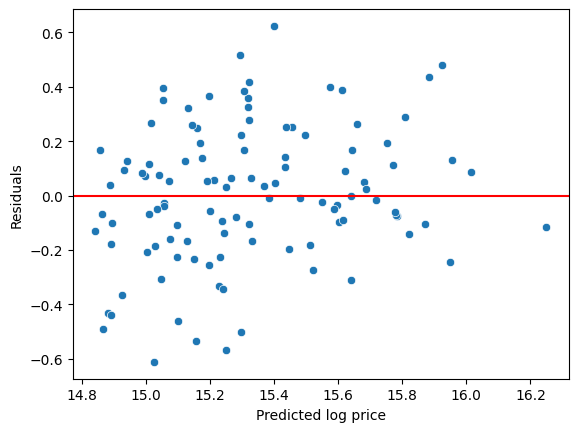

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted log price")
plt.ylabel("Residuals")
plt.show()

In [49]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])


In [50]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'area_per_bedroom'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object'))])),
                ('model', Ridge())])

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE Score:", rmse)
print("MAE Score:", mae)
print("R2 Score:", r2)

RMSE Score: 0.25189359779581727
MAE Score: 0.20015621026523467
R2 Score: 0.6713924533738789


In [23]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
print("Actual RMSE:", rmse_actual)

Actual RMSE: 1316143.3886776625


In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])


In [25]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE (log):", rmse)
print("R2:", r2)

RMSE (log): 0.2669994748936533
R2: 0.6307979629827372


<Axes: xlabel='area', ylabel='log_price'>

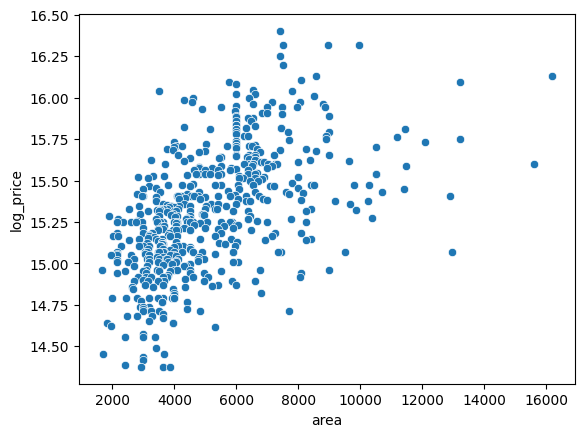

In [26]:
import seaborn as sns
sns.scatterplot(x=df["area"], y=df["log_price"])

In [27]:
df["area_per_bedroom"] = df["area"] / df["bedrooms"]
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["area_per_room"] = df["area"] / df["total_rooms"]